In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from collections import defaultdict

import yaml
import h5py
import tqdm
# from larndsim.fee import digitize


In [4]:
def unique_channel_id(d):
    return ((d['io_group'].astype(int)*1000+((d['io_channel'].astype(int)-1)//4)+1)*1000 \
            + d['chip_id'].astype(int))*100 + d['channel_id'].astype(int)

def unique_to_channel_id(unique):
    return unique % 100

def unique_to_chip_id(unique):
    return (unique// 100) % 1000

def unique_to_io_channel(unique):
    return(unique//(100*1000)) % 1000

def unique_to_tiles(unique):
    return ( (unique_to_io_channel(unique)-1) // 4) + 1

def unique_to_io_group(unique):
    return(unique // (100*1000*1000)) % 1000

def parse_file(filename, max_entries=-1):
    d = dict()
    f = h5py.File(filename, 'r')
    unixtime = f['packets'][:]['timestamp'][f['packets']
                                            [:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)
    data_mask = f['packets'][:]['packet_type'] == 0
    valid_parity_mask = f['packets'][:]['valid_parity'] == 1
    mask = np.logical_and(data_mask, valid_parity_mask)
    adc = f['packets']['dataword'][mask][:max_entries]
    unique_id = unique_channel_id(f['packets'][mask][:max_entries])
    unique_id_set = np.unique(unique_id)
    chips = f['packets']['chip_id'][mask][:max_entries]

    print("Number of packets in parsed files =", len(unique_id))
    for chip in tqdm.tqdm(range(11, 171), desc='parsing data...'):
        _iomask = chips==chip
        _adc = adc[_iomask]
        _unique_id = unique_id[_iomask]
        for i in set(_unique_id):
            id_mask = _unique_id == i
            masked_adc = _adc[id_mask]
            d[i] = dict(
                mean=np.mean(masked_adc),
                std=np.std(masked_adc),
                rate=len(masked_adc) / (livetime + 1e-9))
    return d

def adc_to_ke(adc, vref_dac=223, vcm_dac=68, gain=4.522): #gain is mV/ke-
    vref=vref_dac/256*1800
    vcm=vcm_dac/256*1800
    step = (vref-vcm)/256
    mV = vcm + adc * step
    return mV/gain


## Extract thresholds

In [3]:
pedestal_hdf5 = '/global/cfs/projectdirs/dune/www/data/FSD/nearline/packet/CRS/pedestal_11Nov2024/PRC_256/packet-pedestal-2024_11_12_03_14_21_CET.h5'
leakage_hdf5 = '/global/cfs/projectdirs/dune/www/data/FSD/nearline/packet/CRS/leakage_11Nov2024/p2/packet-leakage-p2-2024_11_11_22_19_28_CET.h5'


In [4]:
dp = parse_file(pedestal_hdf5)

Number of packets in parsed files = 41249029


parsing data...: 100%|██████████| 160/160 [01:08<00:00,  2.35it/s]


In [5]:
dlt = parse_file(leakage_hdf5)

Number of packets in parsed files = 41753609


parsing data...: 100%|██████████| 160/160 [01:03<00:00,  2.50it/s]


In [6]:
dthresh = dict()
means_1=[]
means_2=[]
means_3=[]
means_4=[]

noped = 0

for un in dlt.keys():
    if not un in dp.keys(): 
        noped+=1
        continue
    iog = unique_to_io_group(un)
    thresh = adc_to_ke(dlt[un]['mean']) - adc_to_ke(dp[un]['mean'])
    if thresh < 0: 
        noped += 1
        continue
        
    dthresh[int(un)] = thresh
    if iog == 1: means_1.append(thresh)
    if iog == 2: means_2.append(thresh)
    if iog == 3: means_3.append(thresh)
    if iog == 4: means_4.append(thresh)


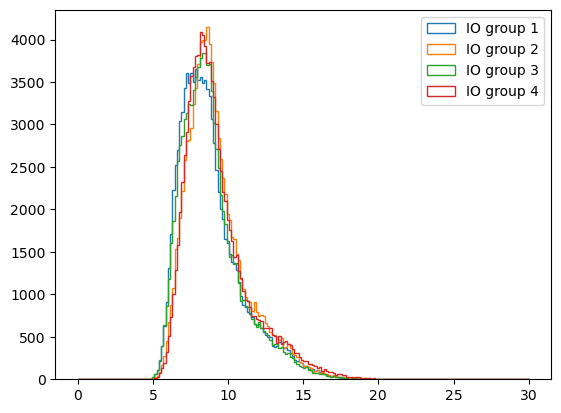

In [7]:
plt.hist(means_1, range=[0,30], bins=200, histtype='step', label='IO group 1');
plt.hist(means_2, range=[0,30], bins=200, histtype='step', label='IO group 2');
plt.hist(means_3, range=[0,30], bins=200, histtype='step', label='IO group 3');
plt.hist(means_4, range=[0,30], bins=200, histtype='step', label='IO group 4');

plt.legend()
# plt.yscale('log')

In [8]:
import json

with open("thresholds_FSD.json", "w") as f:
    json.dump(dthresh, f)


## Save thresholds for `larnd-sim`

In [11]:
import json 

with open('thresholds_FSD.json', 'r') as file:
    all_thresholds = json.load(file)


In [12]:
with open('uniqueid_to_pixelid_fsd.json', 'r') as file:
    unique_id_to_pixel_id = json.load(file)


In [13]:
output_filepath = 'thresholds_fsd.npz'

pixelids = []
thresholds = []

threshold = -1
for io_group in tqdm.tqdm(range(1, 5)):
    for tile in range(1, 11):
        for chip_id in range(11, 171):
            for channel_id in range(64):

                unique_id = str(((io_group*1000+tile)*1000 + chip_id)*100 + channel_id)
                
                if unique_id not in all_thresholds.keys():
                    threshold = 8
                else:
                    threshold = all_thresholds[unique_id]
                
                if threshold < 1: 
                    threshold = 1
                if threshold > 30: 
                    threshold = 30
                

                pixelids.append(unique_id_to_pixel_id[str(unique_id)])
                thresholds.append(threshold*1000)

keys = np.array(pixelids, dtype='int64')
values = np.array(thresholds, dtype='float64')
default = np.array([8000.]) # default value for file 
np.savez(output_filepath, keys=keys, values=values, default=default)

100%|██████████| 4/4 [00:00<00:00,  8.33it/s]


In [9]:
m = np.load('thresholds_fsd.npz')


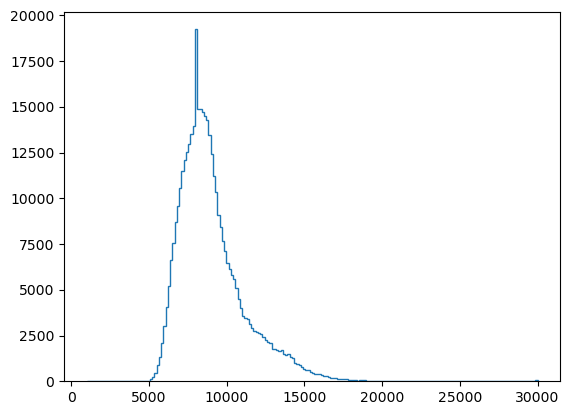

In [10]:
plt.hist(m['values'], histtype='step', bins=200);
